# Lasso Regression

**Lasso** (Least Absolute Shrinkage and Selection Operator) is a regularized linear regression that adds an **L1 penalty** to the loss function. Unlike Ridge, Lasso can drive coefficients **exactly to zero**, performing automatic **feature selection**.

## Cost Function

OLS minimizes:

$$ J(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Lasso adds an **absolute-value** penalty:

$$ J(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j| $$

Where:
- $\alpha \geq 0$ is the regularization strength.
- Larger $\alpha$ → more coefficients become exactly **0**.
- $\alpha = 0$ → equivalent to plain Linear Regression.

## Lasso vs Ridge

| Aspect | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | $\alpha \sum \beta_j^2$ | $\alpha \sum \|\beta_j\|$ |
| Coefficients | Shrunk toward 0, rarely 0 | Many become **exactly 0** |
| Feature selection | No | **Yes** |
| Closed-form | Yes | No (uses coordinate descent) |
| Best when | Many small/medium effects, multicollinearity | Few important features in a sea of irrelevant ones |

## When to use Lasso?
- High-dimensional data where you suspect only a few features actually matter.
- You want a **sparse, interpretable model**.
- Feature selection is part of the goal.

> **Note:** Like Ridge, Lasso requires **standardized features** because the L1 penalty is also scale-sensitive.

---

## 1. Import Required Libraries

In [1]:
# Core libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.datasets import load_diabetes              # Built-in regression dataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler         # Lasso is sensitive to feature scale
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, LassoCV,
    lasso_path
)
from sklearn.metrics import mean_squared_error, r2_score

# Reproducibility
np.random.seed(42)

## 2. Load and Explore the Dataset

We use the **Diabetes** dataset (10 baseline features predicting disease progression).

In [2]:
# Load the diabetes dataset from sklearn
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature matrix shape: (442, 10)
Target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 3. Train / Test Split and Feature Scaling

Lasso's L1 penalty is scale-sensitive, so we standardize features (fit scaler on train only).

In [3]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features: fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size :", X_test_scaled.shape)

Train size: (353, 10)
Test size : (89, 10)


## 4. Baselines: Linear Regression and Ridge

Train these first so we have something to compare Lasso against.

In [4]:
# Plain Linear Regression
lr = LinearRegression().fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Ridge with alpha=1.0
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("Linear Regression")
print(f"  R^2 : {r2_score(y_test, y_pred_lr):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

print("\nRidge (alpha=1.0)")
print(f"  R^2 : {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

Linear Regression
  R^2 : 0.4526
  RMSE: 53.8534

Ridge (alpha=1.0)
  R^2 : 0.4541
  RMSE: 53.7775


## 5. Lasso Regression (fixed alpha)

Fit a Lasso model and look at how many coefficients are forced to exactly **0**.

In [5]:
# Fit Lasso with alpha=1.0
# (Lasso uses coordinate descent under the hood; max_iter is bumped for safe convergence.)
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso (alpha=1.0)")
print(f"  R^2 : {r2_score(y_test, y_pred_lasso):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")

# How many features were eliminated?
n_zero = np.sum(lasso.coef_ == 0)
print(f"  Features set to 0: {n_zero} / {len(lasso.coef_)}")
print(f"  Features kept    : {len(lasso.coef_) - n_zero}")

Lasso (alpha=1.0)
  R^2 : 0.4669
  RMSE: 53.1467
  Features set to 0: 1 / 10
  Features kept    : 9


## 6. Lasso Coefficient Path

Sweep `alpha` and watch coefficients hit **exactly zero** one by one.  
This is the visual signature of L1 regularization (compare with Ridge, where curves only *approach* zero).

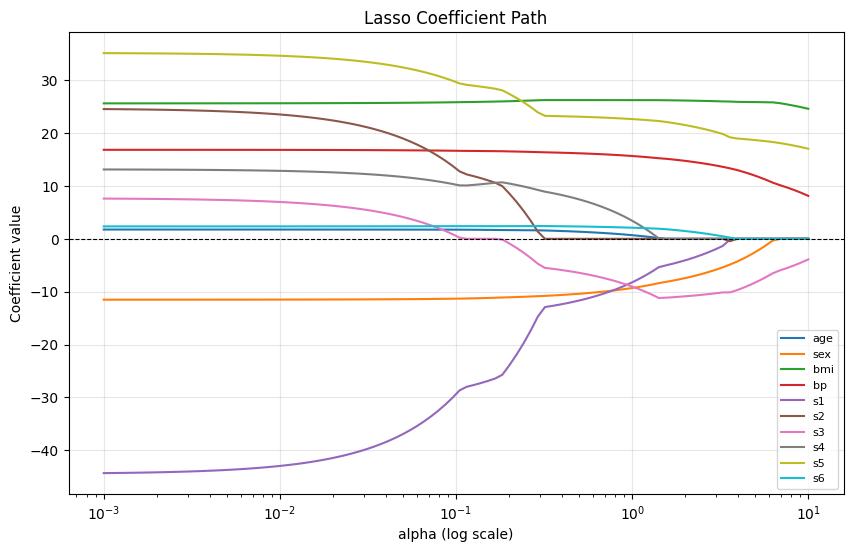

In [6]:
# Compute the Lasso path efficiently with sklearn's lasso_path utility.
# It returns the coefficient values for each alpha along the path.
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    alphas=np.logspace(-3, 1, 100)
)

# coefs_path has shape (n_features, n_alphas)
plt.figure(figsize=(10, 6))
for i, feature in enumerate(X.columns):
    plt.plot(alphas_path, coefs_path[i], label=feature)

plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(loc="best", fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

## 7. Choosing the Best `alpha` with `LassoCV`

`LassoCV` performs k-fold cross-validation along the regularization path and picks the best `alpha` automatically.

In [7]:
# LassoCV: 5-fold CV across a grid of alphas
lasso_cv = LassoCV(
    alphas=np.logspace(-3, 1, 100),
    cv=5,
    max_iter=10000,
    random_state=42,
)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best alpha selected by CV: {lasso_cv.alpha_:.4f}")

# Evaluate the tuned model on the test set
y_pred_cv = lasso_cv.predict(X_test_scaled)
print(f"Tuned Lasso R^2 : {r2_score(y_test, y_pred_cv):.4f}")
print(f"Tuned Lasso RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_cv)):.4f}")

# Number of features kept
n_kept = np.sum(lasso_cv.coef_ != 0)
print(f"Features kept   : {n_kept} / {len(lasso_cv.coef_)}")

Best alpha selected by CV: 1.5557
Tuned Lasso R^2 : 0.4713
Tuned Lasso RMSE: 52.9267
Features kept   : 7 / 10


## 8. Compare Coefficients: Linear vs Ridge vs Lasso

Lasso's column should contain several **exact zeros** — those are the features the model decided are not useful.

In [8]:
comparison = pd.DataFrame({
    "Feature": X.columns,
    "LinearRegression": lr.coef_,
    "Ridge (alpha=1)":  ridge.coef_,
    "Lasso (alpha=1)":  lasso.coef_,
    f"LassoCV (alpha={lasso_cv.alpha_:.3f})": lasso_cv.coef_,
})
comparison

,Feature,LinearRegression,Ridge (alpha=1),Lasso (alpha=1),LassoCV (alpha=1.556)
0,age,1.753758,1.807342,0.687032,0.000000
1,sex,-11.511809,-11.448190,-9.297519,-8.140273
2,bmi,25.607121,25.732699,26.219225,26.198767
3,bp,16.828872,16.734300,15.657314,15.130253
4,s1,-44.448856,-34.671954,-8.228172,-5.019071
5,s2,24.640954,17.053075,-0.000000,-0.000000
6,s3,7.676978,3.369914,-9.024087,-11.129702
7,s4,13.138784,11.764260,3.420861,0.000000
8,s5,35.161195,31.378384,22.636465,22.094483
9,s6,2.351364,2.458139,2.098647,1.817068


## 9. Cross-Validated Error vs `alpha`

`LassoCV` stores the per-fold MSE for every `alpha` in `mse_path_`. We plot the average to confirm the optimum visually.

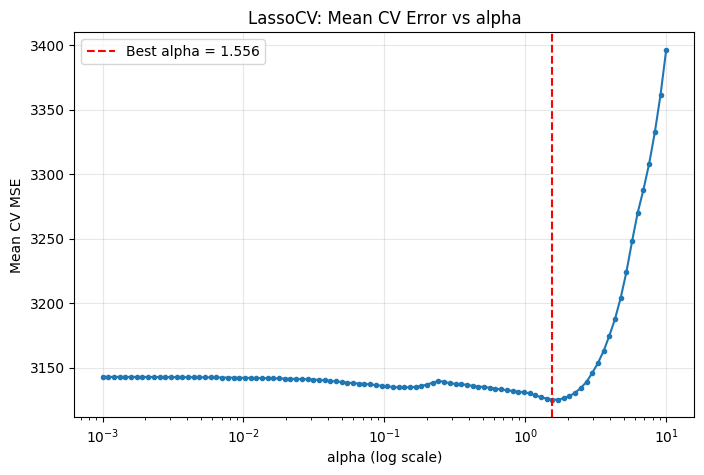

In [9]:
# Average MSE across the 5 folds, for each alpha that LassoCV tried
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mean_mse, marker="o", markersize=3)
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Mean CV MSE")
plt.title("LassoCV: Mean CV Error vs alpha")
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--",
            label=f"Best alpha = {lasso_cv.alpha_:.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Demo: Lasso for Feature Selection

To make Lasso's feature-selection ability really stand out, we add **20 random noise features** to the dataset. A good sparse model should ignore them — i.e. assign coefficient = 0 to all the noise columns.

In [10]:
# Build a noisy version of the dataset by adding 20 random columns
rng = np.random.RandomState(42)
n_noise = 20
noise_cols = [f"noise_{i}" for i in range(n_noise)]

X_noisy = X.copy()
for c in noise_cols:
    X_noisy[c] = rng.randn(len(X))

print("Original feature count:", X.shape[1])
print("Noisy feature count   :", X_noisy.shape[1])

# Same train/test split + standardization on the noisy dataset
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42
)
scaler_n = StandardScaler()
Xn_train_s = scaler_n.fit_transform(Xn_train)
Xn_test_s = scaler_n.transform(Xn_test)

Original feature count: 10
Noisy feature count   : 30


In [11]:
# Fit Ridge and Lasso (CV-tuned) on the noisy dataset
ridge_n = Ridge(alpha=1.0).fit(Xn_train_s, yn_train)

lasso_n = LassoCV(
    alphas=np.logspace(-3, 1, 100),
    cv=5, max_iter=10000, random_state=42,
).fit(Xn_train_s, yn_train)

# Test-set performance
print("Ridge  (noisy data) — R^2 :", round(r2_score(yn_test, ridge_n.predict(Xn_test_s)), 4))
print("Lasso  (noisy data) — R^2 :", round(r2_score(yn_test, lasso_n.predict(Xn_test_s)), 4))
print(f"Lasso best alpha          : {lasso_n.alpha_:.4f}")

# Count how many noise features each model effectively kept
noise_idx = [i for i, c in enumerate(X_noisy.columns) if c.startswith("noise_")]

ridge_noise_kept = np.sum(np.abs(ridge_n.coef_[noise_idx]) > 1e-6)
lasso_noise_kept = np.sum(lasso_n.coef_[noise_idx] != 0)

print(f"\nNoise features with non-zero coefficient:")
print(f"  Ridge: {ridge_noise_kept} / {n_noise}")
print(f"  Lasso: {lasso_noise_kept} / {n_noise}")

Ridge  (noisy data) — R^2 : 0.3635
Lasso  (noisy data) — R^2 : 0.4387
Lasso best alpha          : 2.4771

Noise features with non-zero coefficient:
  Ridge: 20 / 20
  Lasso: 11 / 20


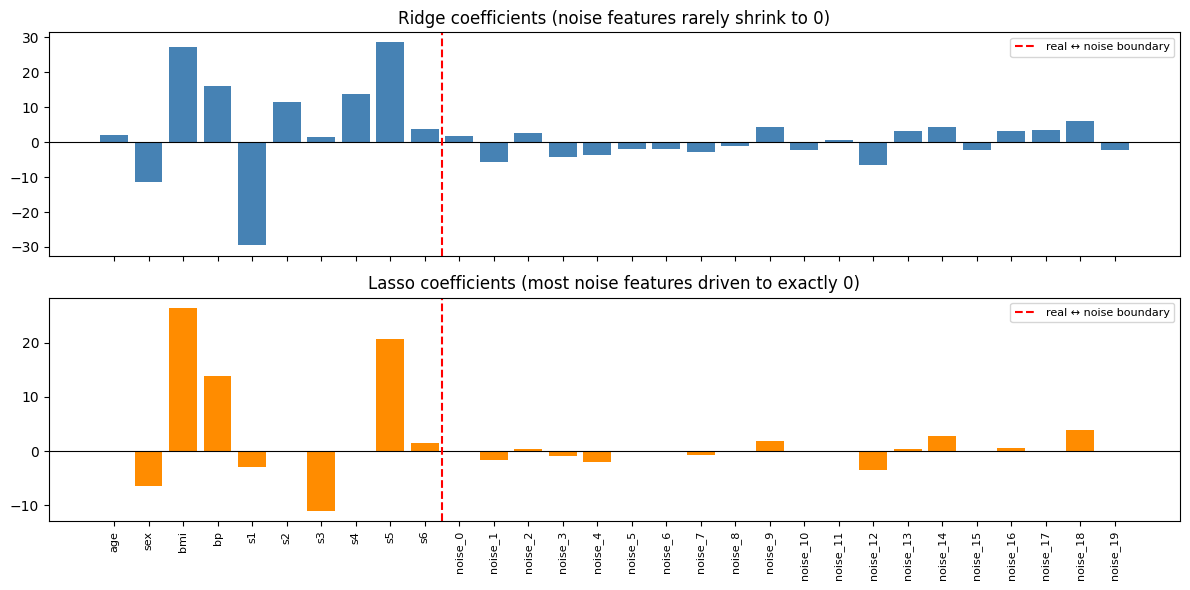

In [12]:
# Visualize: coefficient magnitudes on the noisy dataset.
# Real features = first 10 columns. Noise features = last 20 columns.
features = list(X_noisy.columns)
x_pos = np.arange(len(features))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].bar(x_pos, ridge_n.coef_, color="steelblue")
axes[0].set_title("Ridge coefficients (noise features rarely shrink to 0)")
axes[0].axhline(0, color="black", linewidth=0.8)

axes[1].bar(x_pos, lasso_n.coef_, color="darkorange")
axes[1].set_title("Lasso coefficients (most noise features driven to exactly 0)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(features, rotation=90, fontsize=8)

# Highlight the boundary between real and noise features
for ax in axes:
    ax.axvline(len(X.columns) - 0.5, color="red", linestyle="--",
               label="real ↔ noise boundary")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 11. Summary

- **Lasso = Linear Regression + L1 penalty** $\alpha \sum |\beta_j|$.
- The L1 geometry forces many coefficients to **exactly 0**, giving you **automatic feature selection**.
- Always **standardize** features before fitting (L1 is scale-sensitive).
- Use `LassoCV` to choose the best `alpha` via cross-validation.
- **Ridge vs Lasso:**
  - *Many small/correlated effects* → Ridge tends to do better (it shrinks but keeps everything).
  - *Few strong predictors among many irrelevant ones* → Lasso is preferable.
  - *Both?* → Consider **ElasticNet**, which combines L1 and L2.
- Watch for convergence warnings — bump `max_iter` or rescale data if Lasso complains.